We want to create out-of-distribution (OOD) test/validation data. OOD data would be a previously unseen stimulation condition - cell type combination which will demonstrate if the model generalizes. 

In [17]:
import os
from typing import Optional, Dict, List
import json

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [18]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

In [19]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Kang'

In [20]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))

Let's take a look at how the variables of interest are distributed across the dataset:

In [21]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table = contingency_table.T.sort_values(by = 'Total').T
contingency_table

seurat_annotations,B Activated,DC,NK,T activated,CD8 T,B,CD16 Mono,CD4 Memory T,CD4 Naive T,CD14 Mono,Total
stim,,,,,,,,,,,
CTRL,185,258,298,300,352,407,507,859,978,2215,6359
STIM,203,214,321,333,462,571,537,903,1526,2147,7217
Total,388,472,619,633,814,978,1044,1762,2504,4362,13576


Text(0.5, 0, 'Cell Counts Per Condition')

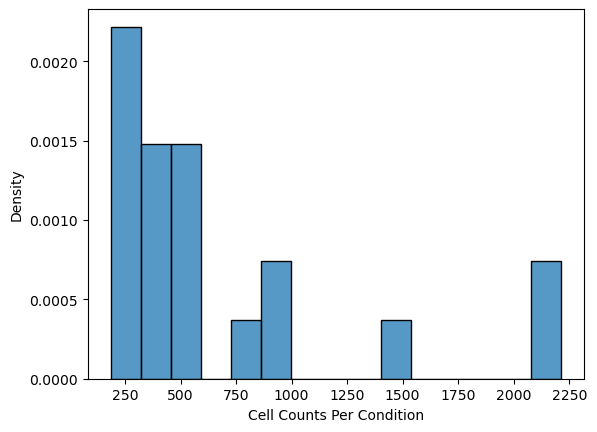

In [22]:
viz_df = contingency_table.drop(columns = ['Total'], index = ['Total'], inplace = False)

fig, ax = plt.subplots()
sns.histplot(viz_df.values.flatten(), bins=15, stat = 'density')
ax.set_xlabel('Cell Counts Per Condition')

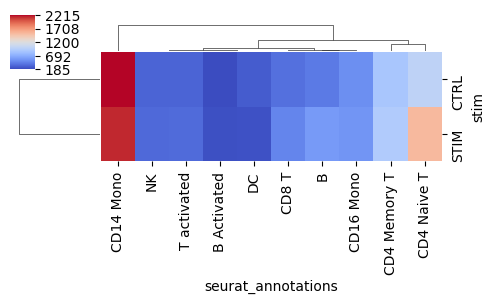

In [23]:
sns.clustermap(viz_df, figsize=(5,3), cmap = 'coolwarm', 
              cbar_kws={"ticks": np.linspace(viz_df.min().min(), viz_df.max().max(), 5)})

We will ensure that each of our folds in our test data have atleast one condition from STIM and one from CTRL, and atleast one condition from each of the four bins below to represent a spread across number of cells:

In [24]:
bins = pd.qcut(tf_adata.obs['seurat_annotations'].value_counts(), q = 4, labels = False)
bins

seurat_annotations
CD14 Mono       3
CD4 Naive T     3
CD4 Memory T    3
CD16 Mono       2
B               2
CD8 T           1
T activated     1
NK              0
DC              0
B Activated     0
Name: count, dtype: int64

We want to generate a train-test splits for 10-fold CV. 

Splitting rules for all folds: referring to condition as the combination of stimulation and cell type
1. cell split and condition split is similar by fraction(conditions is exactly  split, cells is approximate by deviation_thresh)
2. OOD: the test data condition is unseen
3. Each component (stimulation, cell type) of the condition is seen atleast once in the training
4. Each of the two perturbation types are present atleast once in the test
5. The test split needs to contain atleast one of the total bins above (cell type count binning) 

DEPR: Specificaly for the k-fold train-val splits:
- Each validation set has to have atleast two conditions that are distinct from all other validation sets
- Each training follows rule 3 for both the test and validation sets

In [25]:
def ood_split(
    tf_adata,
    train_frac: float,
    pert_col: str = 'stim',
    cat_col: str = 'seurat_annotations',
    cat_bins: Optional[pd.DataFrame] = None,
    cat_bins_frac: float = 1,
    max_iter: int = 1000,
    seed: int = 888,
    deviation_thresh: float = 0.025,
    include_train_cond: Optional[Dict[str, List]] = None):
    """Generate an OOD train test split, where both the condition data and the single-cells have approximately
    the specified split.
    
    Rules: 
    1. cell split and condition split is similar (conditions is exactly the split, 
    cells is approximate by `deviation_thresh`)
    2. Each cell type and perturbation in the test is seen atleast once in the training, OOD is the unique combination of them 
    3. Each of the two perturbations column is present in atleast one test condition
    4. The test split needs to contain atleast one cell type from contex 

    Parameters
    ----------
    tf_adata : 
        AnnData object of TF activity
    train_frac : float
        the fraction of the data going to training
    pert_col : List[str]
        the metadata column defining the stimulation condition
    cat_col: str
        the metadata column of the categorical column, together with stim col defines the OOD split
    cat_bins: Optional[pd.DataFrame]
        binning of the `cat_col`, by default None
    cat_bins_frac: float
        the number of bins that should be included in the test data from the `cat_bins`
    max_iter : int, optional
        total iterations to try to identify a suitable split, by default 1000
    seed : int, optional
        random state variable, by default 888
    deviation_thresh : float, optional
        extent to which to allow the single-cell split to deviate from the specified `train_frac split`, by default 0.025
    include_train_cond : Optional[Dict[str, List]]
        a dictionary with keys for each of pert_col and cat_col and keys as a list that represents a subset
        of values in that column that must be included in the training set. 
        used if generating train-validation-test splits
    """
    test_frac = 1 - train_frac

    condition_cols = [pert_col, cat_col]
    condition_combs = tf_adata.obs[condition_cols].apply(lambda row: '^'.join(row.astype(str)), axis=1)
    unique_conditions = condition_combs.drop_duplicates(keep = 'first', inplace = False).tolist()

    # define the conditions for stopping
    train_frac_deviation = np.inf
    zero_shot_bool = False

    test_stim = False
    n_stims = tf_adata.obs[pert_col].nunique()

    if cat_bins is not None:
        if cat_bins_frac > 1 or cat_bins_frac < 0:
            raise ValueError('The fraction must be between 0 and 1')
        n_contexts = np.floor(cat_bins_frac*cat_bins.nunique())
        context_present = False
    else:
        context_present = True

    if include_train_cond is not None:
        if sorted(set(include_train_cond).intersection(condition_cols)) != sorted(condition_cols):
            raise ValueError('Keys for `include_train_cond` must be the same as `condition_cols`')
        for cond, cond_vals in include_train_cond.items():
            if not set(cond_vals).issubset(tf_adata.obs[cond].tolist()):
                raise ValueError('The conditions to include in training for ' + cond + ' are not present in the metadata.')
        ict_bool = False
    else:
        ict_bool = True
        
        
    counter = 0
    while (train_frac_deviation > deviation_thresh or not zero_shot_bool or not ict_bool or not test_stim or not context_present) and (counter < max_iter):
        # ood at categorical level
        train_cond, test_cond = train_test_split(unique_conditions, test_size = test_frac, random_state = seed + counter, shuffle = True)
        train_cells = condition_combs[condition_combs.isin(train_cond)].index.tolist()
        test_cells = condition_combs[condition_combs.isin(test_cond)].index.tolist()

        train_frac_actual = len(train_cells)/(len(train_cells) + len(test_cells))
        train_frac_deviation = abs(train_frac_actual - train_frac)

        # ensure that all individual conditions are seen atleast once (it's the combination of conditions that's unique)
        train_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            train_cond_map[cond] = {tc.split('^')[idx] for tc in train_cond}

        test_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            test_cond_map[cond] = {tc.split('^')[idx] for tc in test_cond}

        zero_shots = [len(test_cond_map[cond].difference(train_cond_map[cond])) for cond in condition_cols]    
        zero_shot_bool = all(value == 0 for value in zero_shots)

        test_stim = (len(test_cond_map[pert_col]) == n_stims)


        if cat_bins is not None:
            context_present = cat_bins.loc[list(test_cond_map[cat_col])].nunique() >= n_contexts

        if include_train_cond is not None:
            ict_conds = [len(include_train_cond[cond].difference(cond_vals)) for cond, cond_vals in train_cond_map.items()]
            ict_bool = any(value == 0 for value in ict_conds)

        counter += 1

    print(counter)
    if counter < max_iter:
        return train_cells, test_cells, train_cond, test_cond
    else:
        return None, None, None, None
    
    
    
def ood_kfold_split(
    tf_adata,
    n_folds: int,
    pert_col: str = 'stim',
    cat_col: str = 'seurat_annotations',
    cat_bins: Optional[pd.DataFrame] = None,
    cat_bins_frac: float = 1,
    max_iter: int = 1000,
    seed: int = 888,
    deviation_thresh: float = 0.025,
    include_train_cond: Optional[Dict[str, List]] = None
):
    """
    Generate k-fold OOD splits at the condition-combination level.
    Each fold holds out ~1/k of condition combinations as test.

    Keeps resampling fold assignments (via different shuffles) until *all* folds are valid,
    or until max_iter attempts are exhausted.
    """

    condition_cols = [pert_col, cat_col]
    condition_combs = tf_adata.obs[condition_cols].apply(
        lambda row: '^'.join(row.astype(str)), axis=1
    )
    unique_conditions = condition_combs.drop_duplicates(
        keep='first', inplace=False
    ).tolist()

    train_frac_target = (n_folds - 1) / n_folds
    n_stims = tf_adata.obs[pert_col].nunique()

    if cat_bins is not None:
        if cat_bins_frac > 1 or cat_bins_frac < 0:
            raise ValueError('The fraction must be between 0 and 1')
        n_contexts = np.floor(cat_bins_frac * cat_bins.nunique())
    else:
        n_contexts = None

    counter = 0
    while counter < max_iter:

        rng = np.random.default_rng(seed + counter)
        rng.shuffle(unique_conditions)

        folds = np.array_split(unique_conditions, n_folds)

        all_splits = []
        all_valid = True

        for fold_idx in range(n_folds):

            test_cond = folds[fold_idx].tolist()
            train_cond = [
                cond
                for i, f in enumerate(folds)
                if i != fold_idx
                for cond in f.tolist()
            ]

            train_cells = condition_combs[condition_combs.isin(train_cond)].index.tolist()
            test_cells  = condition_combs[condition_combs.isin(test_cond)].index.tolist()

            # ---- begin: unchanged logic from ood_split ----

            train_frac_actual = len(train_cells) / (len(train_cells) + len(test_cells))
            train_frac_deviation = abs(train_frac_actual - train_frac_target)

            train_cond_map = {}
            for idx, cond in enumerate(condition_cols):
                train_cond_map[cond] = {tc.split('^')[idx] for tc in train_cond}

            test_cond_map = {}
            for idx, cond in enumerate(condition_cols):
                test_cond_map[cond] = {tc.split('^')[idx] for tc in test_cond}

            zero_shots = [
                len(test_cond_map[cond].difference(train_cond_map[cond]))
                for cond in condition_cols
            ]
            zero_shot_bool = all(value == 0 for value in zero_shots)

            test_stim = (len(test_cond_map[pert_col]) == n_stims)

            if cat_bins is not None:
                context_present = (
                    cat_bins.loc[list(test_cond_map[cat_col])].nunique()
                    >= n_contexts
                )
            else:
                context_present = True

            if include_train_cond is not None:
                ict_conds = [
                    len(include_train_cond[cond].difference(cond_vals))
                    for cond, cond_vals in train_cond_map.items()
                ]
                ict_bool = any(value == 0 for value in ict_conds)
            else:
                ict_bool = True

            valid = (train_frac_deviation <= deviation_thresh
                     and zero_shot_bool
                     and test_stim
                     and context_present
                     and ict_bool
                    )

            # ---- end: unchanged logic from ood_split ----

            if not valid:
                all_valid = False
                break  

            all_splits.append(
                dict(
                    fold=fold_idx,
                    train_barcodes=train_cells,
                    test_barcodes=test_cells,
                    train_cond=train_cond,
                    test_cond=test_cond,
                )
            )

        if all_valid and len(all_splits) == n_folds:
            return all_splits

        counter += 1

    return None


Create a 5-fold CV split that meets the above requirements:

- Train conditions represent 80% of the data, and train cells represent an approximate similar fraction with a tolerance (+- 5 percentage poitns, i.e., between 75-85% of the data)
- Cell types were binned by their counts/frequency into 4 bins, the test must always include atleast one cell type from 3 of those 4 bins
- Test splits include atleast one condition from both of stim and control perturbations

In [27]:
all_splits = ood_kfold_split(
    tf_adata = tf_adata, 
    n_folds = 5, 
    pert_col = 'stim', 
    cat_col = 'seurat_annotations', 
    cat_bins = bins, 
    cat_bins_frac = 0.75, # 3 of 4 bins includes
    seed = seed, 
    deviation_thresh = 0.05, # within 5% (e.g., trian # of cells is between 75-85%)
    include_train_cond = None, 
    max_iter = int(5e3)
)

# some formatting into dictionary to save as json
all_splits = {
    k:  dict(
        train_barcodes = splits['train_barcodes'], 
        test_barcodes = splits['test_barcodes'], 
        train_conds = splits['train_cond'], 
        test_cond = splits['test_cond']
    ) for (k, splits) in enumerate(all_splits)
}

with open(os.path.join(data_path, 'processed', author + '_5foldCV_splits.json'), "w") as f:
    json.dump(all_splits, f)